In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nChurn Count:\n", df['Churn'].value_counts())

Shape: (7043, 21)

Missing Values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Churn Count:
 Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [3]:
# Drop customerID as it's useless
df = df.drop(['customerID'], axis=1)

# Convert TotalCharges to numeric (it's stored as text)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill any nulls created
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Convert Churn to 0/1
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Cleaned! New shape:", df.shape)
print("Churn values:", df['Churn'].unique())

Cleaned! New shape: (7043, 20)
Churn values: [0 1]


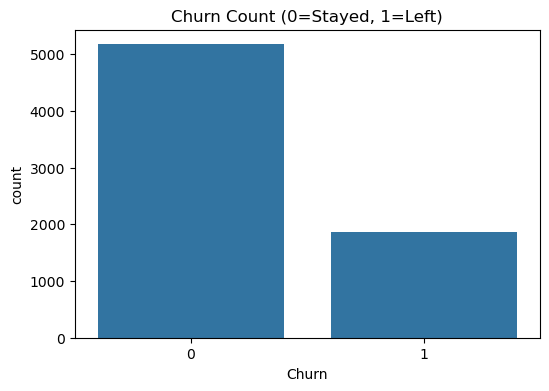

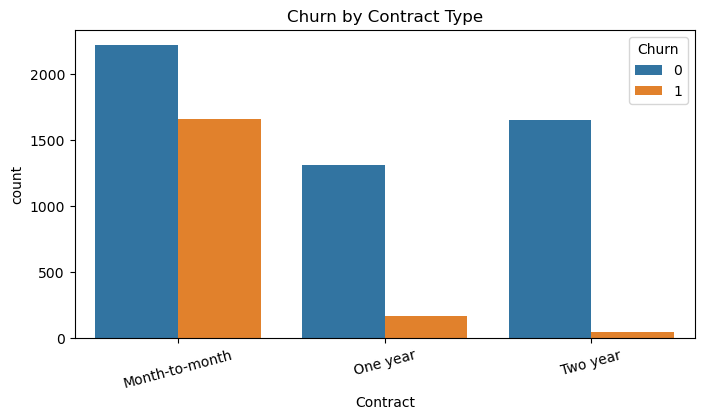

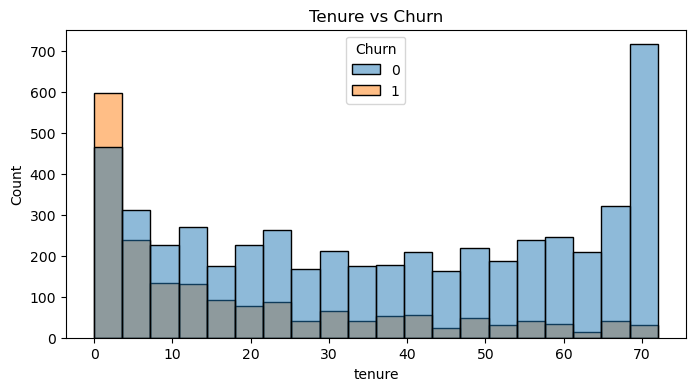

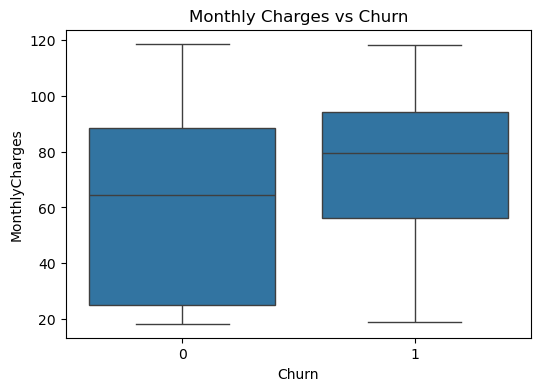

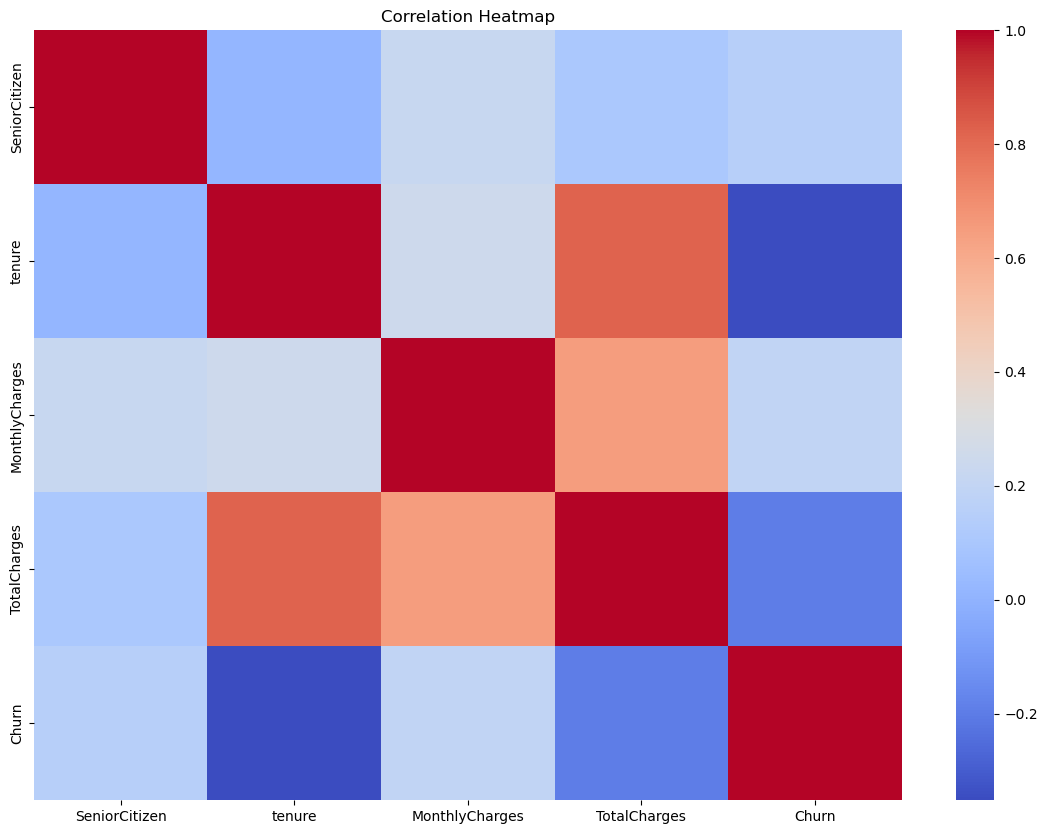

In [4]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title('Churn Count (0=Stayed, 1=Left)')
plt.show()

plt.figure(figsize=(8,4))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn by Contract Type')
plt.xticks(rotation=15)
plt.show()

plt.figure(figsize=(8,4))
sns.histplot(data=df, x='tenure', hue='Churn', bins=20)
plt.title('Tenure vs Churn')
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges vs Churn')
plt.show()

plt.figure(figsize=(14,10))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [5]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

X = df.drop('Churn', axis=1)
y = df['Churn']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nX shape:", X.shape)
print("y shape:", y.shape)
print("Done!")

Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

X shape: (7043, 19)
y shape: (7043,)
Done!


Training size: (5634, 19)
Testing size: (1409, 19)

Logistic Regression Accuracy: 81.55 %
Decision Tree Accuracy: 79.42 %


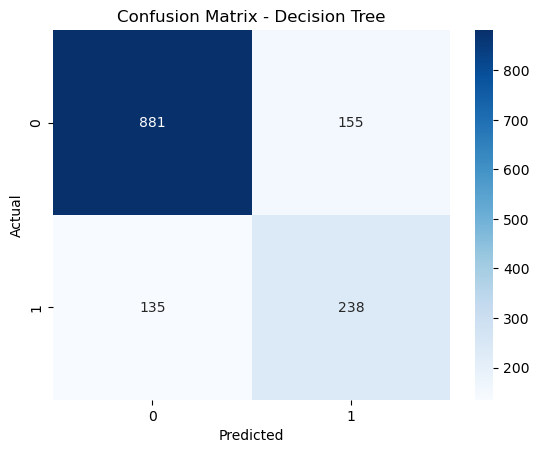


Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.85      0.86      1036
           1       0.61      0.64      0.62       373

    accuracy                           0.79      1409
   macro avg       0.74      0.74      0.74      1409
weighted avg       0.80      0.79      0.80      1409



In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

# Logistic Regression
lr = LogisticRegression(max_iter=2000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("\nLogistic Regression Accuracy:", round(accuracy_score(y_test, y_pred_lr)*100, 2), "%")

# Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("Decision Tree Accuracy:", round(accuracy_score(y_test, y_pred_dt)*100, 2), "%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

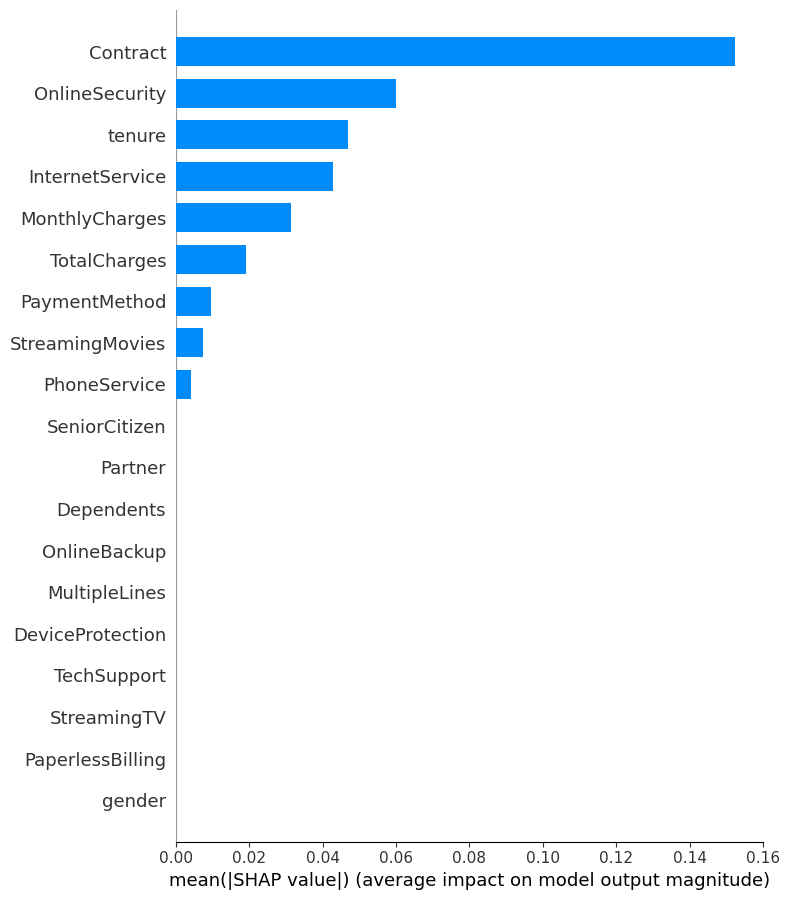

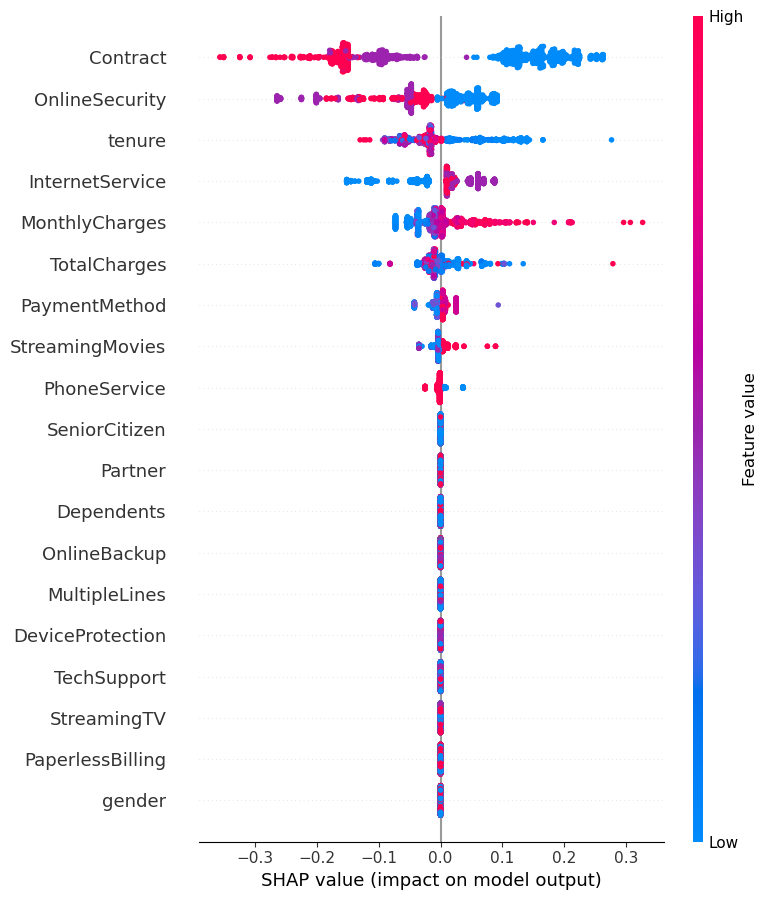

In [7]:
import shap

explainer = shap.TreeExplainer(dt)
shap_values = explainer.shap_values(X_test)

X_test_df = pd.DataFrame(X_test, columns=X.columns)

# Bar plot - which features matter most
shap.summary_plot(shap_values[:,:,1], X_test_df, plot_type="bar")

# Dot plot - detailed view
shap.summary_plot(shap_values[:,:,1], X_test_df)

In [8]:
import pickle

# Save cleaned data for Power BI
df.to_csv('churn_cleaned.csv', index=False)
print("CSV saved!")

# Save model
with open('churn_model.pkl', 'wb') as f:
    pickle.dump(dt, f)
print("Model saved!")

import os
print("Saved at:", os.getcwd())

CSV saved!
Model saved!
Saved at: C:\Users\HOME\Downloads\Customer_Churn
